# Table of Contents

<span style="font-size:16px;">
    
**1.** Data Description <br>
**2.** Data Loading <br>
**3.** Data Preprocessing <br>
**4.** Exploratory Data Analysis (EDA)<br>
**5.** Feature Engineering <br>
**6.** Model Selection <br>
**7.** Model Evaluation <br>
**8.** Test Set <br>
**9.**  Sanity Check <br>
**10.** Visualization <br>
**11.** Conclusion <br>
**12.** Summary <br>

</span>

## Client Churn Prediction for Telecom Company - ML (Imbalanced Classification)

# Task Description

<span style="font-size:16px;">	

`Interconnect Telecom` is facing customer churn: clients are leaving the service over time. Retaining existing customers is much cheaper than acquiring new ones. **Our goal is** to predict whether a customer will leave the company soon using personal, plan, and contract data.

This is a **binary classification** problem, as the target variable is categorical (churn vs. no churn).  
**`AUC-ROC`** score is chosen as the **primary evaluation metric** because it measures the model’s ability to distinguish between churned and retained customers across all classification thresholds  
**`AUC-ROC`** ensures that the model ranks high-risk customers above low-risk ones, which is crucial for targeted retention campaigns. (it should be more than 0.75, preferably **above 0.88**).  
**`Accuracy`** is included as a secondary metric to understand overall correctness. 
</span>

# Data Description  
<span style="font-size:16px;">

The dataset consists of multiple files collected from different sources.  
Each file contains a **`customerID`** column, which uniquely identifies each client.
- **`contract.csv`** — contract information  
- **`personal.csv`** — the client's personal data  
- **`internet.csv`** — information about Internet services  
- **`phone.csv`** — information about telephone services  

### Target:
- **`EndDate`** — indicates whether a customer has left the company  
  - **`'No'`** → customer is still active  
  - **`Date`** → customer has churned

### Features:
- **Contract details** (type, duration, payment method, etc.)  
- **Personal data** (age, gender, location, etc.)  
- **Internet services** (subscription type, add-ons, speed, etc.)  
- **Phone services** (plan type, number of lines, etc.)  

> **Note:** The contract information is valid as of **February 1, 2020**, providing a snapshot of all active clients on that date.

</span>

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  # nice background for charts

import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_curve, roc_auc_score, balanced_accuracy_score

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import shuffle
from sklearn.utils import resample

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import sys
import warnings
warnings.filterwarnings("ignore")
if not sys.warnoptions:
       warnings.simplefilter("ignore")

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

print("Setup Complete")

Setup Complete


# Data Load

In [2]:
files = {
    'contract': 'C:/Users/elesg/OneDrive/Desktop/DS-project/contract.csv',
    'internet': 'C:/Users/elesg/OneDrive/Desktop/DS-project/internet.csv',
    'personal': 'C:/Users/elesg/OneDrive/Desktop/DS-project/personal.csv',
    'phone': 'C:/Users/elesg/OneDrive/Desktop/DS-project/phone.csv'
}

try:
    data = {name: pd.read_csv(path) for name, path in files.items()}
except:
    print("File not found. Check the path.")

### Dataset: `Contract`

In [3]:
data['contract'].head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
# We will merge all dataset together:
df = data['contract']

df = df.merge(data['internet'], on='customerID', how='left')
df = df.merge(data['personal'], on='customerID', how='left')
df = df.merge(data['phone'], on='customerID', how='left')

In [5]:
df.sample(5)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,MultipleLines
4179,8224-DWCKX,2019-02-01,No,Month-to-month,Yes,Credit card (automatic),73.30,828.05,Fiber optic,No,No,No,No,No,No,Male,1,No,No,Yes
5855,2338-BQEZT,2015-07-01,No,Month-to-month,Yes,Credit card (automatic),50.55,2832.75,DSL,Yes,No,No,No,No,No,Female,0,No,No,No
210,7841-TZDMQ,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Credit card (automatic),46.00,84.5,DSL,No,No,No,No,No,No,Male,0,No,No,No
2660,5639-NTUPK,2019-01-01,No,Month-to-month,Yes,Credit card (automatic),52.10,670.65,DSL,Yes,No,No,No,No,No,Male,0,No,Yes,No
6750,2144-ESWKO,2016-07-01,No,One year,Yes,Credit card (automatic),35.20,1463.7,DSL,Yes,No,Yes,No,No,No,Male,0,No,No,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   InternetService   5517 non-null   object 
 9   OnlineSecurity    5517 non-null   object 
 10  OnlineBackup      5517 non-null   object 
 11  DeviceProtection  5517 non-null   object 
 12  TechSupport       5517 non-null   object 
 13  StreamingTV       5517 non-null   object 
 14  StreamingMovies   5517 non-null   object 
 15  gender            7043 non-null   object 
 16  SeniorCitizen     7043 non-null   int64  


### Notes for Preprocessing:
<span style="font-size:16px;">

Following **preprocessing steps** will be performed to prepare the data for modeling:
- Standardize **column names** by converting all feature names to lowercase for consistency and easier handling.  
- Convert **data types** for specific columns:  
`begin_date` and `end_date` → datetime format  
`total_charges` → numeric format
- Create **target variable `churn`** based on the `end_date` column  
- **Check for null values** across all features and handle appropriately:
`total_charges` may contain missing values → fill with `monthly_charge` or impute
- **Create derived features**:  
`tenure_days`- difference between `begin_date` and `end_date` (in days)  
- **Encode categorical columns** using one-hot encoding or similar techniques to make them suitable for ML models.
- **Check for duplicates** and remove if necessary to prevent bias during model training.
- **Analyze numeric features** for potential outliers and inconsistencies to ensure data reliability.
</span>

# Data Preprocessing

### Feature Name Standardization

In [7]:
df.columns = (
    df.columns
      .str.replace('(.)([A-Z][a-z]+)', r'\1_\2', regex=True)
      .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)
      .str.lower()
)

In [8]:
df.head(1)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Female,0,Yes,No,NaN


### Data Type Conversion

In [9]:
df['total_charges'] = pd.to_numeric(
    df['total_charges'],
    errors='coerce'
)

In [10]:
df['begin_date'] = pd.to_datetime(
    df['begin_date'],
    format='%Y-%m-%d'
)

In [11]:
df['end_date'] = pd.to_datetime(
    df['end_date'],
    errors='coerce'
)

### Feature Engineering

In [12]:
df['churn'] = df['end_date'].notna().astype(int)

In [13]:
# the date of data extraction
snapshot_date = pd.to_datetime('2020-02-01')

df['tenure_days'] = (df['end_date'].fillna(snapshot_date) - df['begin_date']).dt.days

### Missing Values Handling

In [14]:
df.isna().sum()

customer_id             0
begin_date              0
end_date             5174
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
gender                  0
senior_citizen          0
partner                 0
dependents              0
multiple_lines        682
churn                   0
tenure_days             0
dtype: int64

In [15]:
# If a customer does not use Internet/phone services, related features may be missing (NaN).  
# Fill these missing values with 'No' to indicate the service is not used.

internet_cols = [
    'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'
]

df[internet_cols] = df[internet_cols].fillna('No')

# we fill 'multiple_lines' with 'not_available'
df['multiple_lines'] = df['multiple_lines'].fillna('not_available')

In [16]:
df[df['total_charges'].isna()]

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,churn,tenure_days
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN,DSL,Yes,No,Yes,Yes,Yes,No,Female,0,Yes,Yes,not_available,0,0
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN,No,No,No,No,No,No,No,Male,0,No,Yes,No,0,0
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN,DSL,Yes,Yes,Yes,No,Yes,Yes,Female,0,Yes,Yes,No,0,0
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN,No,No,No,No,No,No,No,Male,0,Yes,Yes,Yes,0,0
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN,DSL,Yes,Yes,Yes,Yes,Yes,No,Female,0,Yes,Yes,not_available,0,0
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN,No,No,No,No,No,No,No,Male,0,Yes,Yes,No,0,0
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN,No,No,No,No,No,No,No,Male,0,Yes,Yes,Yes,0,0
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN,No,No,No,No,No,No,No,Female,0,Yes,Yes,No,0,0
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN,No,No,No,No,No,No,No,Male,0,Yes,Yes,No,0,0
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN,DSL,No,Yes,Yes,Yes,Yes,No,Female,0,Yes,Yes,Yes,0,0


In [17]:
# Fill missing total_charges for customers who just started with their first monthly charge.

df.loc[df['total_charges'].isna(), 'total_charges'] = df['monthly_charges']

In [18]:
# Count customers with monthly_charges equal to 0 to identify potential anomalies

(df['monthly_charges'] == 0).sum()

np.int64(0)

In [19]:
# Same for 'total_charges' column

(df['total_charges'] == 0).sum()

np.int64(0)

### Duplicate value check

In [20]:
# looking for duplicates, hidden duplicates

print(df.duplicated().sum())

print(df['customer_id'].duplicated().sum())

0
0


In [21]:
df['type'].value_counts()

type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [22]:
df['payment_method'].value_counts()

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [23]:
df['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

<span style="font-size:16px;">

Target variable `churn` is **imbalanced**, with significantly more non-churned customers **(5,174)** than churned customers **(1,869)**
</span>

# Exploratory Data Analysis (EDA)
### Distribution of Numerical Features
### `monthly_charges`

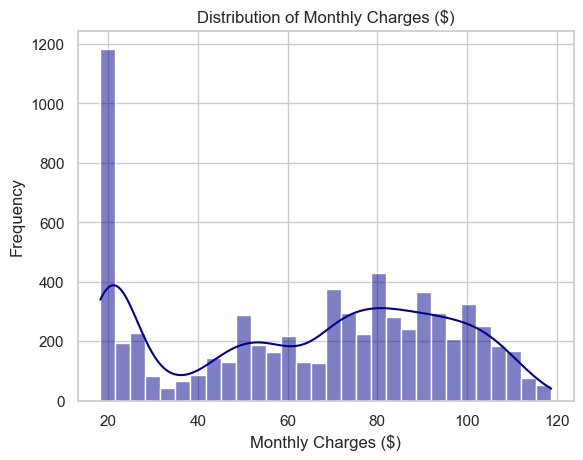

In [24]:
plt.figure()
sns.histplot(df['monthly_charges'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Monthly Charges ($)')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Frequency')
plt.show()

### `total_charges`

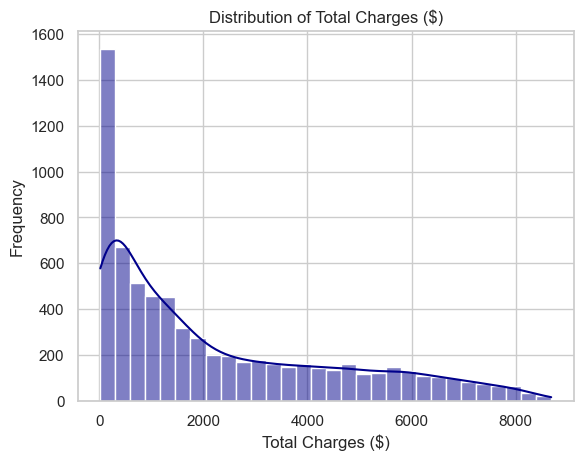

In [25]:
plt.figure()
sns.histplot(df['total_charges'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Total Charges ($)')
plt.xlabel('Total Charges ($)')
plt.ylabel('Frequency')
plt.show()

### `tenure_days`

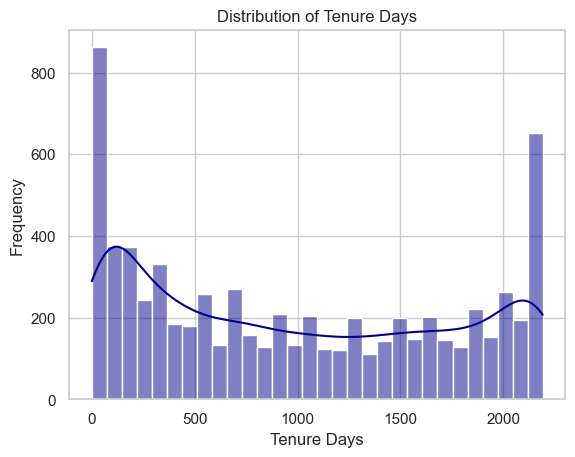

In [26]:
plt.figure()
sns.histplot(df['tenure_days'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Tenure Days')
plt.xlabel('Tenure Days')
plt.ylabel('Frequency')
plt.show()

<span style="font-size:16px;">
    
There are many observations with `total_charges` less than **100 dollars**, which likely correspond to new clients or those who quickly left the company after just one month. At the same time, there is a substantial number of loyal customers who have stayed for over **five years**, as indicated by the `tenure_days` distribution.

`monthly_charges` cluster **around 20 dollars**, suggesting a common plan among clients. **Overall**, aside from these expected variations, there are <br> **no significant outliers**, and the data appears fairly clean for modeling.
</span>

## Target Anaysis

### `churn` vs `gender`

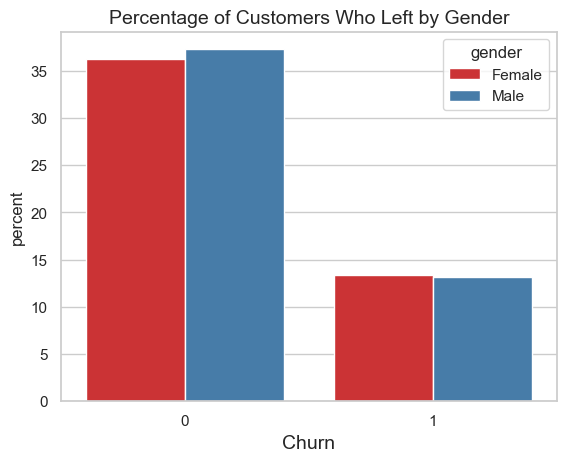

In [27]:
plt.figure()
sns.countplot(x='churn', data=df, stat='percent', hue='gender', palette='Set1')
plt.title('Percentage of Customers Who Left by Gender', fontsize=14)
plt.xlabel('Churn', fontsize=14)
plt.show()

### `type`

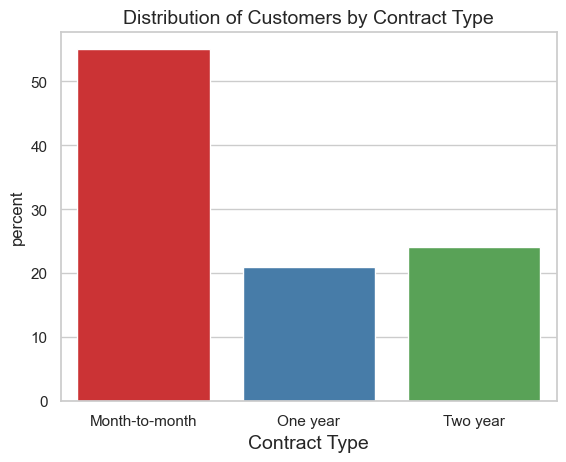

In [28]:
plt.figure()
sns.countplot(x='type', data=df, stat='percent', palette='Set1')
plt.title('Distribution of Customers by Contract Type', fontsize=14)
plt.xlabel('Contract Type', fontsize=14)
plt.show()

<span style="font-size:16px;">
    
Target classes are imbalanced, with at least twice as many customers who stayed than those who left. Imbalanced data can reduce model performance for the minority class, which is more important in this case. We will apply **class balancing techniques** to address this.

`countplot` by gender shows **no significant difference**, so gender does not appear to strongly affect churn in this dataset. <br>
**`month-to-month`** contract is the most commonly used plan among customers.
</span>

# Model Preparation

### Model Preparation:

<span style="font-size:16px;">	

After completing exploratory data analysis (`EDA`) and preprocessing, the dataset is now ready for modeling. The following steps will be applied to prepare the data for `ML algorithms`:
- **Encoding categorical features:**  
  Categorical variables will be transformed using `one-hot encoding` (`pd.get_dummies`) to convert them into a numerical format required by most models.
- **Splitting the data:**  
  The dataset is divided into **training, validation, and test sets** using a **60 / 20 / 20 split**:  
  - **60% Training set** – used to train the models  
  - **20% Validation set** – used for hyperparameter tuning and model selection  
  - **20% Test set** – used for final evaluation   
- **Feature scaling:** <br>
  Numerical features will be **standardized** using `StandardScaler` to **improve model performance** and ensure consistent feature contribution.  

</span>

### Encoding Categorical Features

In [29]:
df_copy = df.copy()

In [30]:
cat_columns = ['paperless_billing', 'type', 'payment_method', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'gender', 'partner', 'dependents', 'multiple_lines']

df_OHE = pd.get_dummies(df_copy, columns=cat_columns, drop_first=True, dtype=int)
df_OHE.head()

,customer_id,begin_date,end_date,monthly_charges,total_charges,senior_citizen,churn,tenure_days,paperless_billing_Yes,type_One year,type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No,online_security_Yes,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,gender_Male,partner_Yes,dependents_Yes,multiple_lines_Yes,multiple_lines_not_available
0,7590-VHVEG,2020-01-01,NaT,29.85,29.85,0,0,31,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
1,5575-GNVDE,2017-04-01,NaT,56.95,1889.50,0,0,1036,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0
2,3668-QPYBK,2019-10-01,2019-12-01,53.85,108.15,0,1,61,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0
3,7795-CFOCW,2016-05-01,NaT,42.30,1840.75,0,0,1371,0,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,1
4,9237-HQITU,2019-09-01,2019-11-01,70.70,151.65,0,1,61,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [31]:
df_OHE.columns = (
    df_OHE.columns
      .str.replace('(.)([A-Z][a-z]+)', r'\1_\2', regex=True)
      .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)
      .str.lower()
      .str.replace(' ', '_')  
)

### Train–Validation–Test Split

In [32]:
df['monthly_charges'].corr(df['total_charges'])

np.float64(0.6511819850393793)

In [33]:
X = df_OHE.drop(['customer_id', 'begin_date', 'end_date', 'churn', 'total_charges'], axis=1)
y = df_OHE['churn']

<span style="font-size:16px;">

**Note:**  
`monthly_charges` and `total_charges` show a moderate **positive correlation (0.65)**. Since `total_charges` is a derived feature (approximately `monthly charges` × `tenure`), it introduces redundant information. To reduce **multicollinearity** and avoid potential **data leakage**, `total_charges` was removed, while keeping `monthly_charges` and `tenure_days`, which provide more direct and interpretable information for the model.

</span>

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=34)

In [35]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=34)

In [36]:
print(f"Training set:   X={X_train.shape}, y={y_train.shape[0]}")
print(f"Validation set: X={X_valid.shape}, y={y_valid.shape[0]}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape[0]}")

Training set:   X=(4507, 22), y=4507
Validation set: X=(1127, 22), y=1127
Test set:       X=(1409, 22), y=1409


### Standard Scaling

In [37]:
numeric = ['tenure_days', 'monthly_charges']

scaler = StandardScaler()
scaler.fit(X_train[numeric])

X_train[numeric] = scaler.transform(X_train[numeric])
X_valid[numeric] = scaler.transform(X_valid[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

In [38]:
X_train.head()

,monthly_charges,senior_citizen,tenure_days,paperless_billing__yes,type__one_year,type__two_year,payment_method__credit_card_(automatic),payment_method__electronic_check,payment_method__mailed_check,internet_service__fiber_optic,internet_service__no,online_security__yes,online_backup__yes,device_protection__yes,tech_support__yes,streaming_tv__yes,streaming_movies__yes,gender__male,partner__yes,dependents__yes,multiple_lines__yes,multiple_lines_not_available
4564,-1.479405,0,-1.272896,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0
3416,0.177964,0,-0.824607,1,0,0,0,0,1,0,0,1,0,0,0,1,1,1,0,1,0,0
3937,-1.474418,0,-1.149415,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5557,0.522072,0,-1.109150,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0
255,-0.164481,0,1.424890,1,0,1,0,1,0,0,0,0,1,1,1,1,1,0,1,1,0,1


# Model Selection

<span style="font-size:16px;">	

For this project, we selected three widely-used **classification algorithms** to predict customer churn:

- `Random Forest`  
- `XGBoost`  
- `LightGBM`  

**1. Hyperparameter Tuning:**  
   - Apply **`GridSearchCV`** to find optimal hyperparameters for each model.  
   - Store results in a DataFrame for clear comparison.  
   - Select the **top two performing models** for more detailed tuning with **`RandomizedSearchCV`**.  

**2. Class Imbalance Handling:**  
   - Use **class weight adjustment** to give higher importance to the minority class.
   - Apply `upsampling` to increase the number of minority class samples, helping the model learn patterns for churned customers.  
   - Since the dataset is relatively small, `downsampling` **will not be applied** to avoid losing valuable information.  

**3. Threshold Optimization:**  
   - Evaluate different probability **thresholds** instead of relying on the default (0.5).  
   - Select the threshold that provides **the best balance** between model performance metrics.  

**4. Model Evaluation:**  
   - Compare models using **`ROC-AUC`** (primary metric) and **`Accuracy`** (secondary metric).  
   - Select the **best-performing model** based on these metrics.  

**5. Final Testing:**  
   - Retrain the selected model on the **combined training and validation data**.  
   - Evaluate performance on the **unseen test set**.  
   - **Visualize** `ROC curve` to better understand model behavior.  

This structured approach ensures that we **identify the most effective model** for predicting churn while making efficient use of the available data.

</span>

## Initial Model Training
### Random Forest (Imbalance)

In [39]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [40]:
model = RandomForestClassifier(random_state=34)

grid_rf = GridSearchCV(
    model,
    param_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [41]:
best_model_rf = grid_rf.best_estimator_

y_pred = best_model_rf.predict(X_valid)
y_proba = best_model_rf.predict_proba(X_valid)[:, 1]

roc_auc_RF = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_RF = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
Random Forest -- Imbalance:

ROC-AUC:             {roc_auc_RF}
Balanced Accuracy:   {balanced_acc_RF}
""")


Random Forest -- Imbalance:

ROC-AUC:             0.87
Balanced Accuracy:   0.74



### XGBoost (Imbalance)

In [42]:
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [43]:
model = XGBClassifier(random_state=34, eval_metric='logloss')

grid_xgb = GridSearchCV(
    model,
    param_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)

{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}


In [44]:
best_model_xgb = grid_xgb.best_estimator_

y_pred = best_model_xgb.predict(X_valid)
y_proba = best_model_xgb.predict_proba(X_valid)[:, 1]

roc_auc_XGB = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_XGB = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
XGBoost -- Imbalance:

ROC-AUC:             {roc_auc_XGB}
Balanced Accuracy:   {balanced_acc_XGB}
""")


XGBoost -- Imbalance:

ROC-AUC:             0.92
Balanced Accuracy:   0.8



### LightGBM (Imbalance)

In [45]:
param_lgbm = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
}

In [46]:
model = LGBMClassifier(random_state=34, verbosity = -1)

grid_lgbm = GridSearchCV(
    model,
    param_lgbm,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_lgbm.fit(X_train, y_train)
print(grid_lgbm.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 0.8}


In [47]:
best_model_lgbm = grid_lgbm.best_estimator_

y_pred = best_model_lgbm.predict(X_valid)
y_proba = best_model_lgbm.predict_proba(X_valid)[:, 1]

roc_auc_LGBM = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_LGBM = round(balanced_accuracy_score(y_valid, y_pred), 2)


print(f"""
LightGBM -- Imbalance:

ROC-AUC:             {roc_auc_LGBM}
Balanced Accuracy:   {balanced_acc_LGBM}
""")


LightGBM -- Imbalance:

ROC-AUC:             0.91
Balanced Accuracy:   0.81



<span style="font-size:16px;">

###  Model Performance Insights:
`Random Forest` shows the weakest performance, particularly in terms of `Balanced Accuracy`, indicating difficulty in handling imbalanced classes.  
`XGBoost` and `LightGBM` outperform `Random Forest`, achieving higher `ROC-AUC` and more stable `Balanced Accuracy` scores.  
`LightGBM` achieves the highest `Balanced Accuracy`, while `XGBoost` delivers the best `ROC-AUC`, suggesting strong classification and ranking capabilities.  
>To further improve performance, the next step is to **apply techniques to handle class imbalance** and retrain the models.

</span>

## Method 1: Class Weight Adjustment
### Random Forest (Balanced)

In [48]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

In [49]:
model = RandomForestClassifier(random_state=34)

grid_rf = GridSearchCV(
    model,
    param_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)

{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [50]:
best_model_rf = grid_rf.best_estimator_

y_pred = best_model_rf.predict(X_valid)
y_proba = best_model_rf.predict_proba(X_valid)[:, 1]

roc_auc_RF_bal = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_RF_bal = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
Random Forest -- Balanced:

ROC-AUC:             {roc_auc_RF_bal}
Balanced Accuracy:   {balanced_acc_RF_bal}
""")


Random Forest -- Balanced:

ROC-AUC:             0.86
Balanced Accuracy:   0.78



### XGBoost (Balanced)

In [51]:
counts = df['churn'].value_counts()

ratio = counts[0] / counts[1]

param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'scale_pos_weight': [ratio]
}

In [52]:
model = XGBClassifier(random_state=34, eval_metric='logloss')

grid_xgb = GridSearchCV(
    model,
    param_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(2.7683253076511503), 'subsample': 1}


In [53]:
best_model_xgb = grid_xgb.best_estimator_

y_pred = best_model_xgb.predict(X_valid)
y_proba = best_model_xgb.predict_proba(X_valid)[:, 1]

roc_auc_XGB_bal = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_XGB_bal = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
XGBoost -- Balanced:

ROC-AUC:            {roc_auc_XGB_bal}
Balanced Accuracy:  {balanced_acc_XGB_bal}
""")


XGBoost -- Balanced:

ROC-AUC:            0.92
Balanced Accuracy:  0.84



In [54]:
importances = best_model_xgb.feature_importances_

# Make a DataFrame for readability
feature_importance_df = pd.DataFrame({
    'feature': X_valid.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

                                    feature  importance
5                            type__two_year    0.417513
4                            type__one_year    0.116706
10                     internet_service__no    0.104012
9             internet_service__fiber_optic    0.093015
16                    streaming_movies__yes    0.034435
2                               tenure_days    0.031190
7          payment_method__electronic_check    0.023266
14                        tech_support__yes    0.021310
21             multiple_lines_not_available    0.020450
11                     online_security__yes    0.016399
0                           monthly_charges    0.014891
1                            senior_citizen    0.012146
3                    paperless_billing__yes    0.011711
17                             gender__male    0.010283
15                        streaming_tv__yes    0.010161
6   payment_method__credit_card_(automatic)    0.009955
20                      multiple_lines__yes    0

### Feature Importance Notes:
<span style="font-size:16px;">

`type` is the **most important predictor** of churn. `internet_service` type and value-added services also influence predictions.`tenure_days`, `payment method`, and other features contribute moderately, while `monthly_charges`, `gender`, and `dependents` have **minor impact**.

>**Overall**, the model relies mainly on contract length and service features to predict churn.
</span>

### LightGBM (Balanced)

In [55]:
param_lgbm = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'class_weight': ['balanced']
}

In [56]:
model = LGBMClassifier(random_state=34, verbosity = -1)

grid_lgbm = GridSearchCV(
    model,
    param_lgbm,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_lgbm.fit(X_train, y_train)
print(grid_lgbm.best_params_)

{'class_weight': 'balanced', 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}


In [57]:
best_model_lgbm = grid_lgbm.best_estimator_

y_pred = best_model_lgbm.predict(X_valid)
y_proba = best_model_lgbm.predict_proba(X_valid)[:, 1]

roc_auc_LGBM_bal = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_LGBM_bal = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
LightGBM -- Balanced:

ROC-AUC:            {roc_auc_LGBM_bal}
Balanced Accuracy:  {balanced_acc_LGBM_bal}
""")


LightGBM -- Balanced:

ROC-AUC:            0.91
Balanced Accuracy:  0.82



<span style="font-size:16px;">

###  Model Performance Insights:
<span style="font-size:16px;">
    
After addressing `class imbalance`, all models show an improvement in `Balanced Accuracy`, indicating better performance on the minority class.  
`Random Forest` improves notably in `Balanced Accuracy` (0.78), although its `ROC-AUC` slightly decreases, suggesting a trade-off between overall ranking and class balance.  
`XGBoost` maintains the highest `ROC-AUC` (0.92) while significantly improving `Balanced Accuracy` (0.84), making it the strongest overall performer after balancing.  
`LightGBM` also benefits from balancing, achieving a `Balanced Accuracy` of 0.82 with stable `ROC-AUC` (0.91), confirming consistent performance.  
>**Overall**, handling class imbalance leads to clear improvements, with `XGBoost` emerging as the **best-performing model** across both metrics.

</span>

## Method 2: Upsampling
<span style="font-size:16px;">
    
`Upsampling` is used to address class imbalance by increasing the number of observations in the minority class.  
The process is performed in the following steps:

- Split the training data into **majority (0)** and **minority (1)** classes  
- **Duplicate the minority class** observations to balance the dataset  
- Combine the duplicated minority samples with the majority class to form a new training set  
- **Shuffle the data** to ensure randomness and prevent the model from learning patterns based on ordering  

To implement this, the dataset will be divided into the following components:

- `features_zeros` — features corresponding to class **0** (non-churn)  
- `features_ones` — features corresponding to class **1** (churn)  
- `target_zeros` — target values for class **0**  
- `target_ones` — target values for class **1**  

These subsets will then be used to construct a **balanced training dataset** through upsampling.
</span>

In [58]:
# Separate classes
df_majority = X_train[y_train==0]
df_minority = X_train[y_train==1]

# Upsample minority
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

# Combine
X_train_up = pd.concat([df_majority, df_minority_upsampled])
y_train_up = pd.concat([y_train[y_train==0], y_train[y_train==1].loc[df_minority_upsampled.index]])

### Random Forest (Upsampled)

In [59]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [60]:
model = RandomForestClassifier(random_state=34)

grid_rf = GridSearchCV(
    model,
    param_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train_up, y_train_up)
print(grid_rf.best_params_)

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [61]:
best_model_rf = grid_rf.best_estimator_

y_pred = best_model_rf.predict(X_valid)
y_proba = best_model_rf.predict_proba(X_valid)[:, 1]

roc_auc_RF_up = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_RF_up = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
Random Forest -- Upsampled:

ROC-AUC:            {roc_auc_RF_up}
Balanced Accuracy:  {balanced_acc_RF_up}
""")


Random Forest -- Upsampled:

ROC-AUC:            0.85
Balanced Accuracy:  0.73



### XGBoost (Upsampled)

In [62]:
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [63]:
model = XGBClassifier(random_state=34, eval_metric='logloss')

grid_xgb = GridSearchCV(
    model,
    param_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train_up, y_train_up)

print(grid_xgb.best_params_)

{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [64]:
best_model_xgb = grid_xgb.best_estimator_

y_pred = best_model_xgb.predict(X_valid)
y_proba = best_model_xgb.predict_proba(X_valid)[:, 1]

roc_auc_XGB_up = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_XGB_up = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
XGBoost -- Upsampled:

ROC-AUC:            {roc_auc_XGB_up}
Balanced Accuracy:  {balanced_acc_XGB_up}

""")


XGBoost -- Upsampled:

ROC-AUC:            0.91
Balanced Accuracy:  0.82




### LightGBM (Upsampled)

In [65]:
param_lgbm = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [66]:
model = LGBMClassifier(random_state=34, verbosity = -1)

grid_lgbm = GridSearchCV(
    model,
    param_lgbm,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_lgbm.fit(X_train_up, y_train_up)
print(grid_lgbm.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.8}


In [67]:
best_model_lgbm = grid_lgbm.best_estimator_

y_pred = best_model_lgbm.predict(X_valid)
y_proba = best_model_lgbm.predict_proba(X_valid)[:, 1]

roc_auc_LGBM_up = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_LGBM_up = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
LightGBM -- Upsampled:

ROC-AUC:            {roc_auc_LGBM_up}
Balanced Accuracy:  {balanced_acc_LGBM_up}

""")


LightGBM -- Upsampled:

ROC-AUC:            0.92
Balanced Accuracy:  0.83




###  Model Performance Insights:
<span style="font-size:16px;">
 
After applying `upsampling`, the models show mixed results compared to class weighting.  
`Random Forest` experiences a decline in both `ROC-AUC` (0.85) and `Balanced Accuracy` (0.73), indicating that upsampling negatively impacts its performance.  
`XGBoost` maintains strong performance with `ROC-AUC` (0.91) and improved `Balanced Accuracy` (0.82), though slightly lower than the class-weighted version.  
`LightGBM` achieves the highest `Balanced Accuracy` (0.83) and strong `ROC-AUC` (0.92), making it the best-performing model under upsampling.  
>**Overall**, upsampling improves performance for boosting models, especially `LightGBM`, while `Random Forest` does not benefit and performs worse compared to other approaches.

</span>

In [68]:
results = pd.DataFrame(
    {
    'model': [ 
              'RF_imbalance', 'XGB_imbalance', 'LGBM_imbalance', 
              'RF_balanced','XGB_balanced','LGBM_balanced', 
              'RF_upsampled','XGB_upsampled','LGBM_upsampled'],
    
    'balanced_accuracy': [
              balanced_acc_RF, balanced_acc_XGB, balanced_acc_LGBM,               
              balanced_acc_RF_bal, balanced_acc_XGB_bal, balanced_acc_LGBM_bal,        
              balanced_acc_RF_up, balanced_acc_XGB_up, balanced_acc_LGBM_up],           
    
    'roc_auc': [
              roc_auc_RF, roc_auc_XGB, roc_auc_LGBM,           
              roc_auc_RF_bal, roc_auc_XGB_bal, roc_auc_LGBM_bal,
              roc_auc_RF_up, roc_auc_XGB_up, roc_auc_LGBM_up]
    }
                            )

In [69]:
print(results)

            model  balanced_accuracy  roc_auc
0    RF_imbalance               0.74     0.87
1   XGB_imbalance               0.80     0.92
2  LGBM_imbalance               0.81     0.91
3     RF_balanced               0.78     0.86
4    XGB_balanced               0.84     0.92
5   LGBM_balanced               0.82     0.91
6    RF_upsampled               0.73     0.85
7   XGB_upsampled               0.82     0.91
8  LGBM_upsampled               0.83     0.92


### Model Performance Visualization

<span style="font-size:16px;">

To compare the performance of different models and sampling strategies, we will **visualize** the `Balanced Accuracy` and `ROC-AUC` scores.  
The `Balanced Accuracy` measures the model’s ability to correctly predict both classes, giving equal importance to the minority class (churned customers), which is crucial in this dataset.  
>**`ROC-AUC`** score provides a measure of overall classification performance, indicating how well the model distinguishes between the classes.  
</span>

In [70]:
balanced_acc = results.sort_values(by='balanced_accuracy', ascending=False)

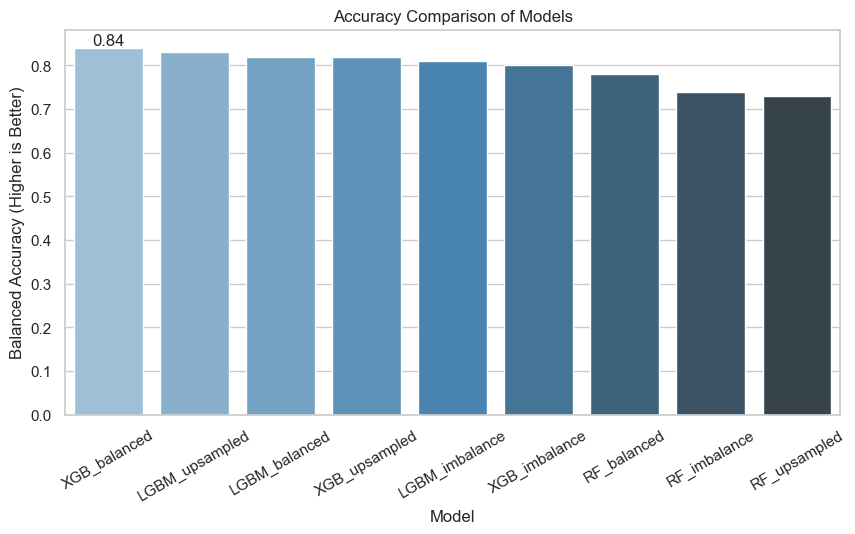

In [71]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x="model", y="balanced_accuracy", data=balanced_acc, palette="Blues_d")
ax.bar_label(ax.containers[0], fmt="%.2f") #The highest score
plt.title("Accuracy Comparison of Models")
plt.ylabel("Balanced Accuracy (Higher is Better)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()

In [72]:
roc_auc_sorted = results.sort_values(by='roc_auc', ascending=False)

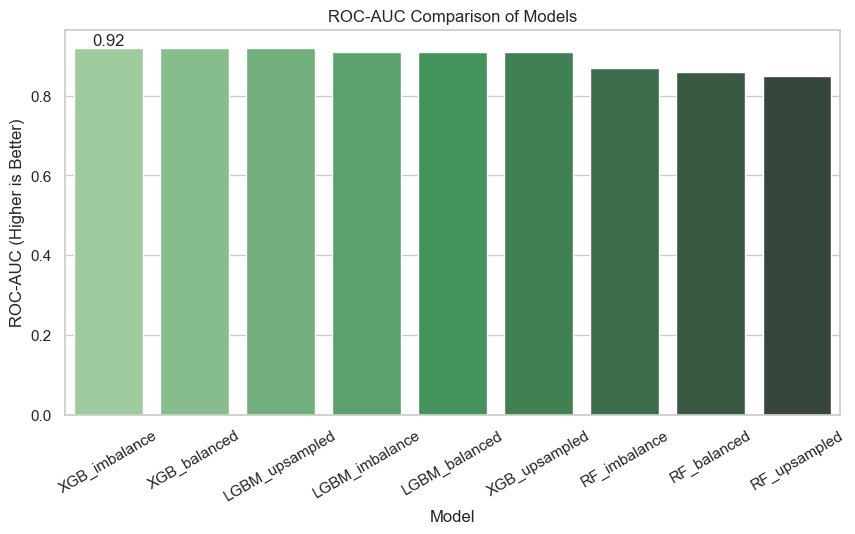

In [73]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x="model", y="roc_auc", data=roc_auc_sorted, palette="Greens_d")
ax.bar_label(ax.containers[0], fmt="%.2f") # The highest score
plt.title("ROC-AUC Comparison of Models")
plt.ylabel("ROC-AUC (Higher is Better)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()

###  Model Performance Insights:

<span style="font-size:16px;">

From the results table:

**Highest** `Balanced Accuracy` is achieved by `LightGBM Upsampled` (0.83), indicating that `LightGBM` with upsampling provides the best balance in correctly predicting both churned and non-churned customers.  
**Highest** `ROC-AUC` is obtained by `XGBoost_balanced` (0.92), showing it has the best overall ability to distinguish between customers who stay and those who leave.  
`Random Forest` improves after balancing techniques, but does not surpass the boosting models.  
`Upsampling` and `class weight adjustment` (balanced) both improve performance, with `LightGBM_up` and `XGBoost_balanced` emerging as the **top performers** overall.  

>**Next**, we will perform **deeper hyperparameter tuning** on the top 2 models (`LightGBM_up` and `XGBoost_balanced`) to potentially achieve even better results. We will evaluate the best models on the test set using the **entire dataset** to confirm their generalization performance.  
We will also **visualize** True Positive Rate (`TPR`), False Positive Rate (`FPR`), `ROC curves` to better understand model behavior on unseen data.

</span>

## Advanced Model Optimization
### LightGBM (Upsampled)

In [74]:
param_lgbm_tuned = {
    'n_estimators': [200, 300, 500],
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

In [75]:
model = LGBMClassifier(random_state=34, verbosity = -1)

random_lgbm = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_lgbm_tuned,
    n_iter=30,                 
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_lgbm.fit(X_train_up, y_train_up)
print(random_lgbm.best_params_)

{'subsample': 1, 'num_leaves': 70, 'n_estimators': 500, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [76]:
best_model_lgbm = random_lgbm.best_estimator_

y_pred = best_model_lgbm.predict(X_valid)
y_proba = best_model_lgbm.predict_proba(X_valid)[:, 1]

roc_auc_LGBM_tuned = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_LGBM_tuned = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
LightGBM -- Final Results:

ROC-AUC:            {roc_auc_LGBM_tuned}
Balanced Accuracy:  {balanced_acc_LGBM_tuned}
""")


LightGBM -- Final Results:

ROC-AUC:            0.91
Balanced Accuracy:  0.8



### XGBoost (Balanced)

In [77]:
param_xgb_tuned = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5],
    'scale_pos_weight': [ratio]
}

In [78]:
model = XGBClassifier(random_state=34, eval_metric='logloss')

random_xgb = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_xgb_tuned,
    n_iter=30,                 
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_xgb.fit(X_train, y_train)
print(random_xgb.best_params_)

{'subsample': 0.8, 'scale_pos_weight': np.float64(2.7683253076511503), 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


In [79]:
best_model_xgb = random_xgb.best_estimator_

y_pred = best_model_xgb.predict(X_valid)
y_proba = best_model_xgb.predict_proba(X_valid)[:, 1]

roc_auc_XGB_tuned = round(roc_auc_score(y_valid, y_proba), 2)
balanced_acc_XGB_tuned = round(balanced_accuracy_score(y_valid, y_pred), 2)

print(f"""
XGBoost -- Final Results:

ROC-AUC:            {roc_auc_XGB_tuned}
Balanced Accuracy:  {balanced_acc_XGB_tuned}
""")


XGBoost -- Final Results:

ROC-AUC:            0.92
Balanced Accuracy:  0.83



### Model Performance Insights:
<span style="font-size:16px;">

After performing deeper hyperparameter tuning on the top models:

`XGBoost` (Balanced) stays same `ROC-AUC` **(0.92)** but `Balanced Accuracy` **(0.83)**, confirming it as the best overall performer in distinguishing between churned and non-churned customers.  
`LightGBM` (Upsampled) shows strong performance with `ROC-AUC` (0.91) and `Balanced Accuracy` (0.80), slightly lower than `XGBoost`, but still highly effective.  
Compared to previous results, tuning improved `XGBoost` in `ROC-AUC`, while `LightGBM` remains consistent, showing stable performance across different imbalance-handling strategies.  

>**Next**, we will loop over different **classification thresholds** to try to further **maximize** `Balanced Accuracy`, then will evaluate `Xgboost` on **test set** for final validation.

</span>

## Threshold Optimization

In [80]:
y_probs = best_model_xgb.predict_proba(X_valid)[:, 1]

best_roc_auc = 0
best_accuracy = 0
best_threshold = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (y_probs > t).astype(int)
    
    roc_auc_val = round(roc_auc_score(y_valid, y_probs), 2)
    acc_val = round(balanced_accuracy_score(y_valid, preds), 2)
    
    if acc_val > best_accuracy:
        best_accuracy = acc_val
        best_roc_auc = roc_auc_val
        best_threshold = t

print(f"""
Best Threshold:     {best_threshold:.2f}
ROC-AUC:            {best_roc_auc}
Balanced Accuracy:  {best_accuracy}
""")


Best Threshold:     0.42
ROC-AUC:            0.92
Balanced Accuracy:  0.84



### Threshold Optimization Insights:
<span style="font-size:16px;">

By looping over `classification thresholds`, we identified the optimal **`threshold` = 0.42**, which improves the model’s performance:

`ROC-AUC` remains high **(0.92)**, indicating excellent overall ranking ability.  
`Balanced Accuracy` **improves to 0.84**, showing a better balance in correctly predicting both churned and non-churned customers.  

>This demonstrates that adjusting the decision threshold can significantly **enhance model performance**, especially in imbalanced datasets.  

</span>

# Test Set

In [81]:
xgb_test = random_xgb.best_estimator_

y_proba = xgb_test.predict_proba(X_test)[:, 1]
y_pred = (y_proba > best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)              
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"""
XGBoost -- Test Set (with Best Threshold):

ROC-AUC:            {roc_auc:.2f}
Balanced Accuracy:  {balanced_acc:.2f}
""")


XGBoost -- Test Set (with Best Threshold):

ROC-AUC:            0.90
Balanced Accuracy:  0.80



### Test Set Insights:
<span style="font-size:16px;">

`XGBoost` model with tuned hyperparameters and optimal **threshold** (0.42) performs well on the test set:

`Balanced Accuracy`: 0.80 → shows strong ability to correctly predict both churned and non-churned customers.
`ROC-AUC`: 0.90 → indicates excellent overall discrimination between customers who stay and those who leave.

Compared to training results, the test metrics are slightly lower but remain strong, suggesting that the model generalizes well and is **not overfitting.**  <br>
Applying class balancing during training and tuning the decision threshold helps the model handle the minority class effectively without overemphasizing the majority class.

>**Next**, we will retrain and evaluate the best models on the **full dataset** to maximize predictive performance and prepare the model for deployment.

</span>

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=34)

In [83]:
print(f"Training set:   X={X_train.shape}, y={y_train.shape[0]}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape[0]}")

Training set:   X=(5634, 22), y=5634
Test set:       X=(1409, 22), y=1409


In [84]:
# Using these numeric columns
numeric = ['tenure_days', 'monthly_charges']

scaler = StandardScaler()
scaler.fit(X_train[numeric])

X_train[numeric] = scaler.transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

In [85]:
best_xgb_final = XGBClassifier(random_state=34, eval_metric='logloss', 
                               subsample = 1, 
                               num_leaves = 70, 
                               n_estimators = 300, 
                               learning_rate = 0.1, 
                               colsample_bytree = 0.8)

best_xgb_final.fit(X_train, y_train)
y_pred = best_xgb_final.predict(X_test)
y_proba = best_xgb_final.predict_proba(X_test)[:, 1]

y_pred = (y_proba > best_threshold).astype(int)

roc_auc_final = roc_auc_score(y_test, y_proba)              
balanced_acc_final = balanced_accuracy_score(y_test, y_pred)

print(f"""
XGBoost -- Full Dataset:

ROC-AUC:            {roc_auc_final:.2f}
Balanced Accuracy:  {balanced_acc_final:.2f}
""")


XGBoost -- Full Dataset:

ROC-AUC:            0.92
Balanced Accuracy:  0.83



### Final Model Insights: (Full Dataset)
<span style="font-size:16px;">

`XGBoost` model with tuned hyperparameters and **optimal threshold**, trained on the entire dataset, shows **excellent** predictive performance:

`Balanced Accuracy`: **0.83** → improves over the test set (0.83), indicating even better balance in correctly predicting both churned and non-churned customers.
`ROC-AUC`: **0.92** → slightly higher than the test set (0.90), confirming strong overall discrimination between customers who stay and those who leave.

Compared to the test set results, training on the full dataset provides **slightly better performance**, demonstrating that the model effectively leverages all available data while maintaining generalization.

>**Next**, we will **visualize** `ROC curve` to gain deeper insights into model behavior and ensure robust performance across classes.

</span>

## `ROC Curve`

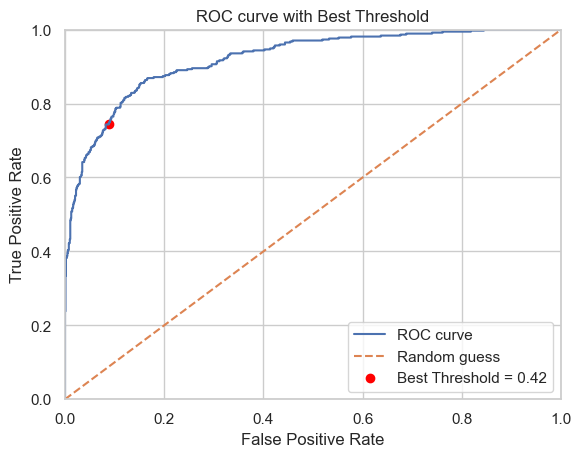

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

best_thresh = 0.42
# Find index closest to best threshold
idx = np.argmin(np.abs(thresholds - best_thresh))
best_fpr = fpr[idx]
best_tpr = tpr[idx]

plt.figure()
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
plt.scatter(best_fpr, best_tpr, color='red', label=f'Best Threshold = {best_thresh}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.ylim([0.0, 1.0])
plt.xlim([0.0, 1.0])
plt.title('ROC curve with Best Threshold')
plt.legend()
plt.show()

### ROC Curve Analysis
<span style="font-size:16px;">

The `ROC curve` is created by comparing the true target values with the predicted probabilities of the positive class (churn).
It provides three key elements:
`FPR` – False Positive Rate
`TPR` – True Positive Rate
`Threshold` values used to convert probabilities into class predictions

**Interpretation:**

`A random classifier` produces a diagonal ROC line from bottom-left to top-right.
**The higher** the `ROC curve`, **the better** the model distinguishes between customers who stay and those who leave.
**By marking the best threshold (0.42)** on the curve, we can see the point where `Balanced Accuracy` is maximized, improving prediction for both classes.
</span>

# Summary

<span style="font-size:16px;">
    
In this project, I developed a **binary classification model** to analyze clients’ past behavior and contract termination data to predict whether a customer is likely to leave the company.

### Preprocessing:
- Performed **descriptive statistics** to explore the data and identified missing values.
- **Standardized** column names by converting all feature names to lowercase for consistency and easier handling.
- Converted **data types** for specific columns:

- `begin_date` and `end_date` → datetime format
- `total_charges` → numeric format

- **Created the target variable `churn`** based on the `end_date` column:  
  - `churn = 1` if `end_date` is not `'No'`  
  - `churn = 0` if `end_date` is `'No'`

- **Checked for null values** across all features and handled appropriately:
  - `total_charges` missing values → filled with `monthly_charge`

- **Created derived features**:  
  - `tenure_days` = difference between `begin_date` and `end_date` (in days)
  - 
- **`One-Hot Encoded`** categorical features.
- **Checked for duplicates** to prevent bias during model training.

### Exploratory Data Analysis (EDA):
- No significant **outliers** were observed; the data was kept as is, with the option to revisit this step after modeling.
- The **month-to-month** contract is the most commonly used plan among customers.
- `Monthly_charges` cluster around **20 dollars**, suggesting a common plan among clients.
- Many observations with `total_charges` less than **100 dollars**, which likely correspond to new clients or those who quickly left the company after just one month. 

### Model Preparation:
- The target classes are **imbalanced**: <br>
There are more than twice as many customers who stayed than those who left. To address this, the `stratify` parameter was used during the **train-test split** to preserve the target distribution.

Additional imbalance-handling strategies applied include:
- **Class Weight Adjustment**
- **Upsampling**

### Hyperparameter Tuning:
- The top-performing algorithms — **`Random Forest`, `XGBoost`, and `LightGBM`** — were **tuned** to identify optimal hyperparameters.
- For the best models, we also **looped over thresholds** to maximize **`Balanced Accuracy`**, ensuring better performance on both classes.

### Best Model:
- **`XGBoost` (Balanced, Tuned, Threshold Optimized)** emerged as the **best model**:
  - **`ROC-AUC`:** 0.92 (training)
  - **`Balanced Accuracy`:** 0.84 (training at optimal threshold)

- On the **test set**, it achieved:
  - **`ROC-AUC`:** 0.90
  - **`Balanced Accuracy`:** 0.80

- When retrained on the **entire dataset**, the model improved slightly:
  - **`ROC-AUC`:** 0.92
  - **`Balanced Accuracy`:** 0.83

This confirms that the model **generalizes well** and effectively captures patterns in both churned and non-churned customers.

### Insights & Visualization:
- ROC curves and threshold analysis show the **model’s strong ability to distinguish between classes**.
- Adjusting the **decision threshold** improves **Balanced Accuracy**, making the predictions more reliable for imbalanced data.
- Next step includes visualizing **ROC curve** to gain a detailed understanding of model performance.

</span>

### ========================= Conclusion ===============================
<span style="font-size:16px;">

**Final Model Performance** (`Xgboost`):  
**ROC-AUC:** 0.92 <br>
**Balanced Accuracy:** 0.83  

</span>